# Exploratory Data Analysis — Deutsche Bahn Train Delays

Dataset: [`piebro/deutsche-bahn-data`](https://huggingface.co/datasets/piebro/deutsche-bahn-data)
(data by **Deutsche Bahn**, CC BY 4.0) — 24 monthly parquet files, 2024-07 → 2026-06,
**148.4M station-stop rows** total.

Goal of this notebook: understand the data well enough to write a trustworthy ingest +
validation pipeline, and produce the data-quality findings documented in the README.
Every section ends with a **Finding** box. All heavy computation runs through polars
lazy queries, so nothing here needs more than a few GB of RAM despite the 6.5 GB dataset.

> Run `make data` first to download the raw files.

In [1]:
import matplotlib.pyplot as plt
import polars as pl

from dbahn_delay.config import settings

RAW_GLOB = str(settings.monthly_raw_dir / "*.parquet")
lf = pl.scan_parquet(RAW_GLOB)

files = sorted(settings.monthly_raw_dir.glob("*.parquet"))
print(f"{len(files)} monthly files, {sum(f.stat().st_size for f in files) / 1e9:.1f} GB")
print(f"columns: {lf.collect_schema().names()}")

Matplotlib is building the font cache; this may take a moment.


24 monthly files, 6.5 GB
columns: ['station_name', 'xml_station_name', 'eva', 'train_number', 'line_number', 'final_destination_station', 'delay_in_min', 'time', 'is_canceled', 'train_type', 'train_line_ride_id', 'train_line_station_num', 'arrival_planned_time', 'arrival_change_time', 'departure_planned_time', 'departure_change_time', 'id']


## 1. Monthly volume and station coverage

The dataset has two eras: before 2025-11 it covers only the ~100 busiest stations,
afterwards (nearly) all stations in Germany.

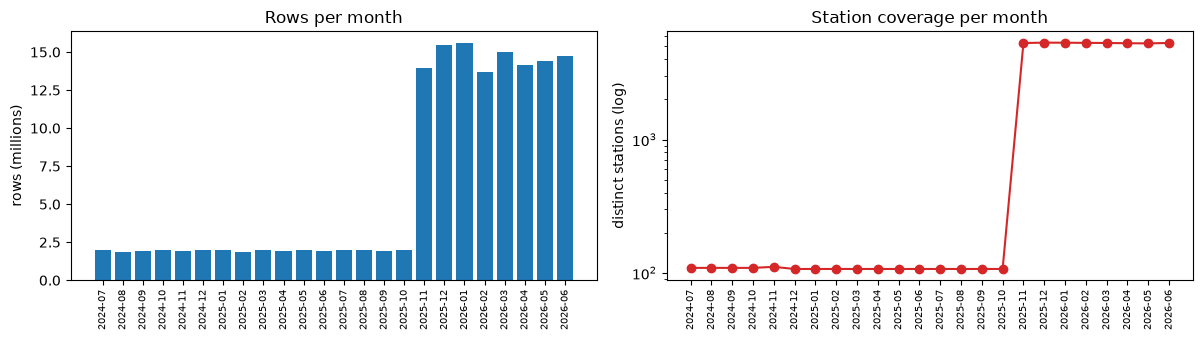

month,rows,stations,cancel_rate,delayed6_rate
str,u32,u32,f64,f64
"""2024-07""",2007251,109,0.052991,0.168107
"""2024-08""",1888035,109,0.051166,0.164806
"""2024-09""",1904404,109,0.056145,0.173441
"""2024-10""",1984484,109,0.054254,0.17466
"""2024-11""",1901651,111,0.050998,0.192439
…,…,…,…,…
"""2026-02""",13721520,5304,0.036715,0.14374
"""2026-03""",15016329,5299,0.030917,0.143058
"""2026-04""",14149788,5273,0.031593,0.140501


In [2]:
per_month = (
    lf.group_by(pl.col("time").dt.strftime("%Y-%m").alias("month"))
    .agg(
        rows=pl.len(),
        stations=pl.col("station_name").n_unique(),
        cancel_rate=pl.col("is_canceled").mean(),
        delayed6_rate=(pl.col("delay_in_min") >= 6).mean(),
    )
    .sort("month")
    .collect()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].bar(per_month["month"], per_month["rows"] / 1e6, color="#1f77b4")
axes[0].set_ylabel("rows (millions)")
axes[0].set_title("Rows per month")
axes[1].plot(per_month["month"], per_month["stations"], marker="o", color="#d62728")
axes[1].set_yscale("log")
axes[1].set_ylabel("distinct stations (log)")
axes[1].set_title("Station coverage per month")
for ax in axes:
    ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

per_month

**Finding 1 — coverage regime change.** 2025-10 → 2025-11 jumps from **107 to ~5,300
stations** (~2M to ~15M rows/month). Naively training on "all data" would make the model
believe thousands of stations suddenly appeared — a fake drift signal. The ingest
pipeline therefore restricts to a *consistent station panel*: the 107 early-era stations,
all of which remain present in the late era.

## 2. Delay distribution

`delay_in_min` is the regression target. How is it shaped?

shape: (8, 2)
┌────────────────────┬──────────────┐
│ column             ┆ column_0     │
│ ---                ┆ ---          │
│ str                ┆ f64          │
╞════════════════════╪══════════════╡
│ n                  ┆ 1.48351038e8 │
│ p50                ┆ 1.0          │
│ p90                ┆ 9.0          │
│ p99                ┆ 37.0         │
│ min                ┆ -1446.0      │
│ max                ┆ 1475.0       │
│ negative_share     ┆ 0.009322     │
│ delayed_6min_share ┆ 0.159808     │
└────────────────────┴──────────────┘


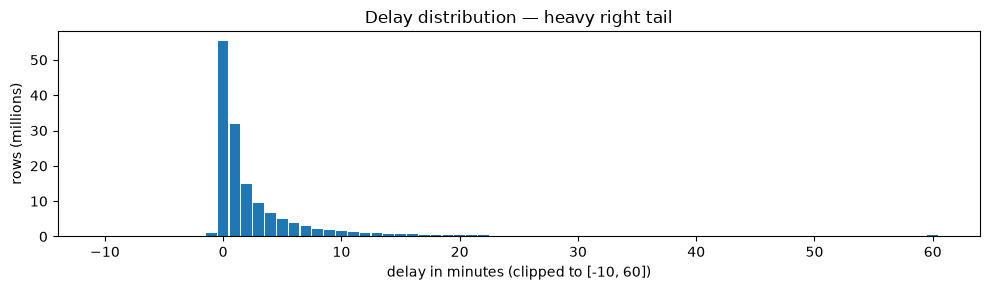

In [3]:
stats = lf.select(
    n=pl.len(),
    p50=pl.col("delay_in_min").quantile(0.5),
    p90=pl.col("delay_in_min").quantile(0.9),
    p99=pl.col("delay_in_min").quantile(0.99),
    min=pl.col("delay_in_min").min(),
    max=pl.col("delay_in_min").max(),
    negative_share=(pl.col("delay_in_min") < 0).mean(),
    delayed_6min_share=(pl.col("delay_in_min") >= 6).mean(),
).collect()
print(stats.transpose(include_header=True))

# Full-value histogram via group_by (no sampling): clip to [-10, 60] for display
hist = (
    lf.select(delay=pl.col("delay_in_min").clip(-10, 60))
    .group_by("delay")
    .len()
    .sort("delay")
    .collect()
)
plt.figure(figsize=(10, 3))
plt.bar(hist["delay"], hist["len"] / 1e6, width=0.9, color="#1f77b4")
plt.xlabel("delay in minutes (clipped to [-10, 60])")
plt.ylabel("rows (millions)")
plt.title("Delay distribution — heavy right tail")
plt.tight_layout()
plt.show()

**Finding 2 — heavy tail + sentinel values.** Median delay is **1 minute**, p90 = 9,
p99 = 37 — but the extremes reach **±24 hours** (min −1446, max 1475 min). Values
clustering at exactly ±1440 are day-shift artifacts, not real operations (a handful per
month, ~0.003% of rows). Validation treats anything outside **[−60, +1440] min** as a
data error; the tolerant raw profile allows a ≤0.01% trickle, the processed dataset
allows none. About **0.9%** of delays are negative (early departures) — legitimate and
kept.

## 3. Delay by train type

Is train category informative? (Spoiler: it is the single strongest low-hanging feature.)

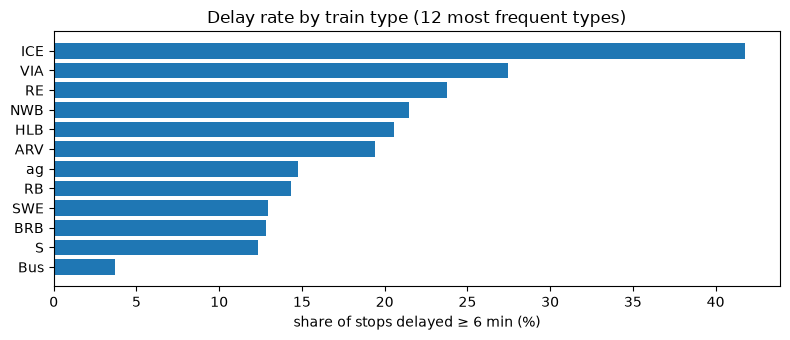

train_type,rows,delayed6,p50,p90
str,u32,f64,f64,f64
"""S""",65496419,0.123617,1.0,7.0
"""RB""",20084322,0.143568,1.0,8.0
"""RE""",17155371,0.237779,1.0,13.0
"""ICE""",3785268,0.418008,4.0,33.0
"""Bus""",3597423,0.037056,0.0,1.0
…,…,…,…,…
"""VIA""",2025273,0.27438,2.0,15.0
"""NWB""",2018656,0.214548,1.0,10.0
"""ARV""",1615517,0.194404,1.0,10.0


In [4]:
by_type = (
    lf.group_by("train_type")
    .agg(
        rows=pl.len(),
        delayed6=(pl.col("delay_in_min") >= 6).mean(),
        p50=pl.col("delay_in_min").quantile(0.5),
        p90=pl.col("delay_in_min").quantile(0.9),
    )
    .sort("rows", descending=True)
    .head(12)
    .collect()
)

plt.figure(figsize=(8, 3.5))
order = by_type.sort("delayed6")
plt.barh(order["train_type"], order["delayed6"] * 100, color="#1f77b4")
plt.xlabel("share of stops delayed ≥ 6 min (%)")
plt.title("Delay rate by train type (12 most frequent types)")
plt.tight_layout()
plt.show()

by_type

**Finding (modeling) — train type separates strongly.** **41.8% of ICE stops** are
delayed ≥ 6 min (p90 = 33 min!) versus **12.4% for S-Bahn** and 23.8% for RE. Long-distance
trains accumulate delay over long routes; S-Bahn systems have short, buffered loops. Any
model must beat a baseline that already knows this split.

## 4. Base rate over time — the drift story

The classification target is `delay >= 6 min`. Is its base rate stable?

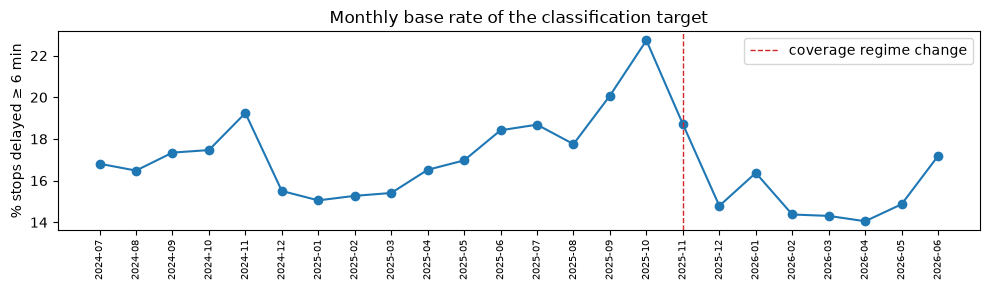

In [5]:
plt.figure(figsize=(10, 3))
plt.plot(per_month["month"], per_month["delayed6_rate"] * 100, marker="o")
plt.axvline(x="2025-11", color="#d62728", ls="--", lw=1, label="coverage regime change")
plt.ylabel("% stops delayed ≥ 6 min")
plt.title("Monthly base rate of the classification target")
plt.legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

**Finding 3 — the target itself drifts.** The monthly base rate swings between **14%
and 22.7%** (peak: 2025-10). Part is seasonal (autumn storms, construction season), part
is the coverage change (small stations are more punctual, so the all-station era dilutes
the rate). Consequences: (a) evaluation must be time-aware — a random split would leak
seasonal regimes; (b) monitoring must track the base rate, not just model metrics.

## 5. Cancellations

4.4% of stops are canceled. What does `delay_in_min` mean for them?

In [6]:
canceled = (
    lf.filter(pl.col("is_canceled"))
    .select(
        n=pl.len(),
        delay_p50=pl.col("delay_in_min").quantile(0.5),
        delay_zero_share=(pl.col("delay_in_min") == 0).mean(),
    )
    .collect()
)
print(canceled)

shape: (1, 3)
┌─────────┬───────────┬──────────────────┐
│ n       ┆ delay_p50 ┆ delay_zero_share │
│ ---     ┆ ---       ┆ ---              │
│ u32     ┆ f64       ┆ f64              │
╞═════════╪═══════════╪══════════════════╡
│ 6524420 ┆ 0.0       ┆ 0.689191         │
└─────────┴───────────┴──────────────────┘


**Finding 4 — delay is meaningless for canceled stops.** 6.5M rows are canceled and
**69% of them report delay = 0** — a canceled train is not "on time", the field is simply
not populated meaningfully. Canceled rows are kept in the canonical dataset (flagged),
but must be **excluded from the delay regression target**. Cancellation prediction is its
own (harder) problem.

## 6. Missingness

In [7]:
schema_cols = lf.collect_schema().names()
nulls = (
    lf.select([(pl.col(c).null_count() / pl.len()).alias(c) for c in schema_cols])
    .collect()
    .transpose(include_header=True, header_name="column", column_names=["null_rate"])
    .sort("null_rate", descending=True)
)
nulls

column,null_rate
str,f64
"""arrival_planned_time""",0.106878
"""arrival_change_time""",0.106848
"""departure_planned_time""",0.106619
"""departure_change_time""",0.106586
"""line_number""",0.037167
…,…
"""is_canceled""",0.0
"""train_type""",0.0
"""train_line_ride_id""",0.0


In [8]:
# Are arrival/departure nulls structural (route endpoints) rather than data loss?
endpoint_check = (
    lf.group_by(
        first_stop=pl.col("train_line_station_num")
        == pl.col("train_line_station_num").min().over("train_line_ride_id"),
    )
    .agg(arrival_null_rate=pl.col("arrival_planned_time").is_null().mean(), rows=pl.len())
    .collect()
)
print(endpoint_check)

shape: (2, 3)
┌────────────┬───────────────────┬───────────┐
│ first_stop ┆ arrival_null_rate ┆ rows      │
│ ---        ┆ ---               ┆ ---       │
│ bool       ┆ f64               ┆ u32       │
╞════════════╪═══════════════════╪═══════════╡
│ false      ┆ 0.0               ┆ 130353684 │
│ true       ┆ 0.880985          ┆ 17997354  │
└────────────┴───────────────────┴───────────┘


**Finding 5 — nulls are mostly structural, with one exception.** `arrival_*` and
`departure_*` are each ~10.7% null: a train's **first stop has no arrival** and its
**last stop has no departure** — expected route-endpoint structure, confirmed above.
`line_number` is 3.7% null (long-distance trains often carry no line number). The real
quality issue: **`station_name` is null for up to 2.35% of rows in early-era months**
(~0.01% later) — those rows are unusable and dropped by ingest; `xml_station_name` is
never null and could back-fill them in a future iteration.

Also verified here: **`id` has zero duplicates across all 148M rows**, and the dataset
card's schema is outdated (files carry `train_number`/`line_number`, not `train_name` —
trust the files, not the docs).

## 7. Timezone / DST sanity

Timestamps are naive local Europe/Berlin times. If true, the spring-forward hour
(2025-03-30 02:00–03:00) must not exist in the data.

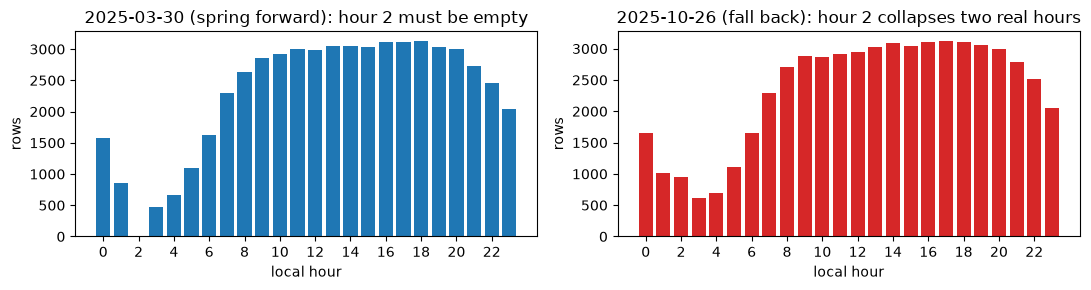

confirmed: timestamps are naive Europe/Berlin wall-clock times


In [9]:
def hourly_counts(day: pl.Expr) -> pl.DataFrame:
    return (
        lf.filter(pl.col("time").dt.date() == day)
        .group_by(pl.col("time").dt.hour().alias("hour"))
        .len()
        .sort("hour")
        .collect()
    )


spring = hourly_counts(pl.date(2025, 3, 30))  # clocks jump 02:00 -> 03:00
fall = hourly_counts(pl.date(2025, 10, 26))  # 02:00-03:00 happens twice

fig, axes = plt.subplots(1, 2, figsize=(11, 3), sharey=False)
axes[0].bar(spring["hour"], spring["len"], color="#1f77b4")
axes[0].set_title("2025-03-30 (spring forward): hour 2 must be empty")
axes[1].bar(fall["hour"], fall["len"], color="#d62728")
axes[1].set_title("2025-10-26 (fall back): hour 2 collapses two real hours")
for ax in axes:
    ax.set_xlabel("local hour")
    ax.set_ylabel("rows")
    ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

assert 2 not in spring["hour"].to_list(), "hour 2 exists on spring-forward day!?"
print("confirmed: timestamps are naive Europe/Berlin wall-clock times")

**Finding 6 — timestamps are naive Berlin wall-clock time.** Hour 02 is entirely absent
on 2025-03-30 (spring forward), and on 2025-10-26 the repeated 02:00–03:00 hour collapses
into a single wall-clock hour (the two physical hours are indistinguishable). The ingest
pipeline attaches `Europe/Berlin` explicitly, resolving ambiguous fall-back stamps to the
earliest occurrence — so downstream feature code can never mix up UTC and local time.

## Summary — data quality findings (also in README)

1. **Coverage regime change 2025-11**: 107 → ~5,300 stations. Ingest restricts to the
   consistent 107-station panel.
2. **Heavy-tailed target with ±24 h sentinels**: median 1 min, p99 = 37 min; day-shift
   artifacts outside [−60, +1440] min are validated away (≤ 0.01% tolerated raw, 0%
   processed).
3. **The classification base rate drifts** month to month (14% → 22.7%): time-aware
   validation and base-rate monitoring are mandatory.
4. **Delay is meaningless for canceled stops** (69% report 0): canceled rows are flagged
   and excluded from regression targets.
5. **Nulls are structural at route endpoints** (arrival/departure ~10.7%); the true
   defect is null `station_name` (≤ 2.35% early-era, dropped at ingest). Zero duplicate
   ids across 148M rows; the dataset card schema is outdated — the files are the truth.